In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
#get the datasets
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

x1 = torch.load("/content/drive/MyDrive/amass_tensors/bmlmovi_tensor.pt")
x2 = torch.load("/content/drive/MyDrive/amass_tensors/bmlrub_tensor.pt")
x3 = torch.load("/content/drive/MyDrive/amass_tensors/cmu_tensor.pt")

X = torch.cat((x1, x2, x3), dim=0)

n1 = int(0.8*len(X))
n2 = int(0.9*len(X))

device = "cuda" if torch.cuda.is_available() else "cpu"

train_set = X[:n1].to(device)
val_set = X[n1:n2].to(device)
test_set = X[n2:].to(device)

print("X: ")
print(X.shape)
print("----------------")
print("train_set: ")
print(train_set.shape)
print("test_set: ")
print(test_set.shape)
print("val_set: ")
print(val_set.shape)

Mounted at /content/drive
X: 
torch.Size([8489716, 156])
----------------
train_set: 
torch.Size([6791772, 156])
test_set: 
torch.Size([848972, 156])
val_set: 
torch.Size([848972, 156])


In [ ]:
#find mean and std of the training set
mean = train_set.mean(dim=0)
var  = train_set.var(dim=0)

In [ ]:
#normalise the dataset
train_set = (train_set-mean)/torch.sqrt(var + 1e-8)
val_set = (val_set-mean)/torch.sqrt(var + 1e-8)
test_set = (test_set-mean)/torch.sqrt(var + 1e-8)

In [ ]:
#hyperparameters
num_layers  = 10
action_dim  = 156
d_model     = 256
num_heads   = 8
max_seq     = 128
_batch_size = 128
_lr         = 1e-4

#encoder
class ActionEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Linear(action_dim, d_model)

    def forward(self, x):
        # x shape: (batch, seq, action_dim)
        return self.proj(x)
        # output shape: (batch, seq, d_model)


#transformer block
class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn  = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model)
        )

    def forward(self, x):
        normed = self.norm1(x)
        T = x.shape[1]
        mask = torch.nn.Transformer.generate_square_subsequent_mask(T).to(device)
        x = x + self.attn(normed, normed, normed, attn_mask=mask, is_causal=True)[0]
        x = x + self.ffn(self.norm2(x))

        return x

#decoder
class ActionDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Linear(d_model, action_dim)

    def forward(self, x):
        # x shape: (batch, seq, d_model)
        return self.proj(x)
        # output shape: (batch, seq, action_dim)


#full unimodal model
class Mars(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = ActionEncoder()
        self.pos_emb = nn.Embedding(max_seq, d_model)
        self.blocks  = nn.ModuleList([TransformerBlock() for _ in range(num_layers)])
        self.decoder = ActionDecoder()

    def forward(self, x):
        # x shape: (batch, seq, action_dim)
        x = self.encoder(x)
        positions = torch.arange(x.shape[1], device=x.device)
        x = x + self.pos_emb(positions)
        for block in self.blocks:
            x = block(x)
        # decode last token, that's the next frame prediction
        x = self.decoder(x[:, -1, :])
        # output shape: (batch, action_dim)
        return x

model = Mars().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=_lr)
loss_fn = nn.MSELoss()

In [ ]:
#lets train
def train_step(data, batch_size=_batch_size):
    max_start = data.shape[0] - max_seq - 1
    starts = torch.randint(0, max_start, (batch_size,))
    input = torch.stack([data[s : s+max_seq] for s in starts])
    target = torch.stack([data[s+max_seq] for s in starts])

    pred = model(input)
    loss = loss_fn(pred, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

def train(data, val_data, n_steps=1000):
    losses, val_losses = [], []
    for step in range(n_steps):
        loss = train_step(data)
        losses.append(loss)
        if step % 50 == 0:
            val_loss = test(val_set)
            val_losses.append((step, val_loss))
            print(f"step {step:6d}  train {loss:.6f}  val {val_loss:.6f}")
    return losses, val_losses

#test
def test(seq, n_windows=500):
    model.eval()
    losses = []
    max_start = seq.shape[0] - max_seq - 1
    with torch.no_grad():
        for _ in range(n_windows):
            s = torch.randint(0, max_start, (1,)).item()
            input  = seq[s : s + max_seq].unsqueeze(0)
            target = seq[s + max_seq].unsqueeze(0)
            pred   = model(input)
            loss   = loss_fn(pred, target)
            losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)

In [ ]:
losses, val_losses = train(train_set, val_set, n_steps=2000)

step      0  train 0.994489  val 0.793570
step     50  train 0.141715  val 0.174947
step    100  train 0.077213  val 0.083984
step    150  train 0.044945  val 0.050376
step    200  train 0.027464  val 0.038388
step    250  train 0.017761  val 0.026709
step    300  train 0.017095  val 0.021682
step    350  train 0.012648  val 0.017570
step    400  train 0.011466  val 0.013865
step    450  train 0.010687  val 0.013144
step    500  train 0.007580  val 0.010860
step    550  train 0.007500  val 0.010052
step    600  train 0.005588  val 0.010041
step    650  train 0.005965  val 0.008176
step    700  train 0.005500  val 0.006763
step    750  train 0.005440  val 0.009559
step    800  train 0.004567  val 0.006985
step    850  train 0.003904  val 0.005897
step    900  train 0.008643  val 0.006304
step    950  train 0.006713  val 0.005867
step   1000  train 0.004784  val 0.004690
step   1050  train 0.004038  val 0.006309
step   1100  train 0.003466  val 0.004917
step   1150  train 0.002941  val 0

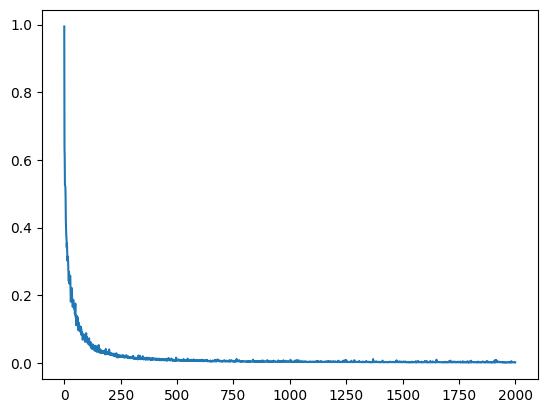

In [ ]:
plt.plot(losses)

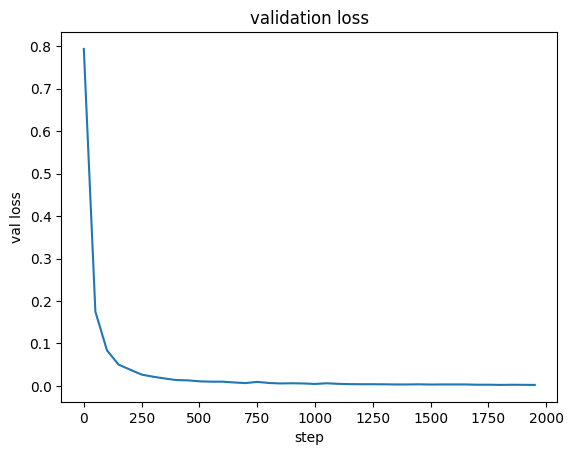

In [ ]:
steps = [x[0] for x in val_losses]
vals  = [x[1] for x in val_losses]
plt.plot(steps, vals)
plt.xlabel('step')
plt.ylabel('val loss')
plt.title('validation loss')
plt.show()

In [ ]:
print(f"test loss: {test(test_set, n_windows=500)}")

test loss: 0.0022239733206806706


In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/mars_v10.pt')

In [16]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

model = Mars().to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/mars_v10.pt"))

Mounted at /content/drive


<All keys matched successfully>

In [17]:
#generate autoregressive motion
def generate_motion(model, seed_seq, n_seed=128, n_steps=300):
    model.eval()
    seed = seed_seq[:n_seed].clone().cpu()
    generated = seed.clone()

    with torch.no_grad():
        for _ in range(n_steps):
            input_seq = generated[-max_seq:].unsqueeze(0).to(device)
            pred = model(input_seq).squeeze(0).cpu()
            generated = torch.cat([generated, pred.unsqueeze(0)], dim=0)

    #denormalize
    generated_real = generated * torch.sqrt(var.cpu() + 1e-8) + mean.cpu()
    return generated_real.numpy()  # shape (n_seed + n_steps, 156)

#any sequence from test set
seed = test_set[1000:1000+128].cpu()  #128 frames from test set

motion = generate_motion(model, seed)
print(motion.shape)  #shape (428, 156)

import numpy as np
np.save('/content/drive/MyDrive/generated_motion_v10.npy', motion)
print("saved")

(428, 156)
saved
